# MedAESQA EDA

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# load data
with open("../data/medaesqa_v1.json", "r") as f:
    data = json.load(f)

len(data)

40

## Structure

In [2]:
# main fields
data[0].keys()

dict_keys(['question_id', 'question', 'question_frame', 'expert_curated_answer', 'machine_generated_answers', 'nuggets'])

In [3]:
# basic counts
num_questions = len(data)
num_machine_answers = sum(len(q["machine_generated_answers"]) for q in data)
num_nuggets = sum(len(q["nuggets"]) for q in data)

print("questions:", num_questions)
print("machine answers:", num_machine_answers)
print("expert nuggets:", num_nuggets)

questions: 40
machine answers: 1200
expert nuggets: 498


## Missing values

In [4]:
# check top-level fields
fields = list(data[0].keys())

missing = {
    field: sum(
        q.get(field) is None
        or q.get(field) == ""
        or q.get(field) == []
        or q.get(field) == {}
        for q in data
    )
    for field in fields
}

pd.Series(missing, name="missing").to_frame()

,missing
question_id,0
question,0
question_frame,0
expert_curated_answer,0
machine_generated_answers,0
nuggets,0


## Questions

In [5]:
# question metadata
question_rows = []

for q in data:
    row = {
        "question_id": q["question_id"],
        "question": q["question"],
        "question_words": len(q["question"].split()),
        "num_nuggets": len(q["nuggets"]),
    }
    row.update(q["question_frame"])
    question_rows.append(row)

questions_df = pd.DataFrame(question_rows)
questions_df.head()

,question_id,question,question_words,num_nuggets,Focus,Type,Task,Subject matter (focus),Body system,Specialty,Agent,Title,The Follow-Up of Eating Disorders from Adolescence to Early Adulthood,Location,Condition,Intervention,Symptom
0,116,Are there ways to prevent sleep apnea or treat...,11,19,sleep apnea,Treatment,Decision support,clinical / problem,respiratory,pulmonology/ ENT / cardiology,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,117,What will mutation in runx2 affect in the future?,9,10,runx2 mutation,Manifestation,Effect,genetics,full body,clinical genetics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,118,how long does a minor cornea injury take to he...,13,3,corneal abrasion,Prognosis,Factoid,clinical / problem,visual,ophthalmology,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,119,what drug or combination of drugs is most popu...,14,16,COPD,Treatment,Decision support,clinical / problem,respiratory,pulmonology,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,120,what causes left sided facial numbness?,6,9,facial numbness,Etiology,Factoid,clinical / problem,nervous,neurology,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# task types
questions_df["Task"].value_counts()

Task
Effect              14
Factoid             12
Decision Support    10
Decision support     4
Name: count, dtype: int64

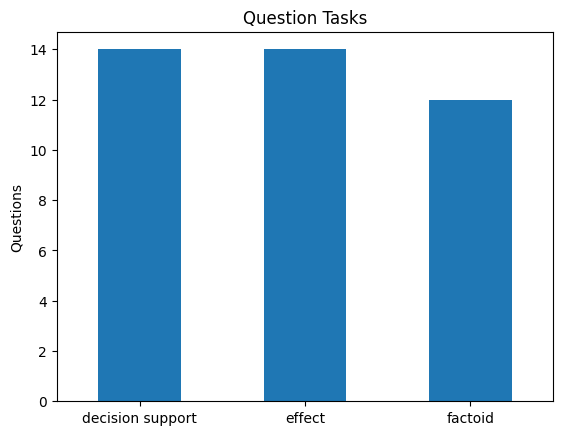

In [7]:
# clean capitalization for the plot
questions_df["task_clean"] = questions_df["Task"].str.lower()

questions_df["task_clean"].value_counts().plot(kind="bar")
plt.title("Question Tasks")
plt.xlabel("")
plt.ylabel("Questions")
plt.xticks(rotation=0)
plt.show()

In [8]:
# subject types
questions_df["Subject matter (focus)"].value_counts()

Subject matter (focus)
clinical / problem         22
clinical / drug             8
clinical / intervention     6
genetics                    4
Name: count, dtype: int64

## Answers

In [9]:
# machine answers
answer_rows = []

for q in data:
    for method, answer in q["machine_generated_answers"].items():
        answer_rows.append({
            "question_id": q["question_id"],
            "method": method,
            "answer": answer["answer"],
            "accurate": answer["is_answer_accurate"],
            "answer_words": len(answer["answer"].split())
        })

answers_df = pd.DataFrame(answer_rows)
answers_df.head()

,question_id,method,answer,accurate,answer_words
0,116,M1,There are several natural ways to prevent and ...,yes,152
1,116,M2,"To prevent and treat sleep apnea naturally, se...",yes,117
2,116,M3,There are several natural ways to prevent and ...,yes,146
3,116,M4,There are several natural ways to prevent and ...,yes,152
4,116,M5,There is no natural way to prevent sleep apnea...,no,87


In [10]:
# answer lengths
expert_lengths = [len(q["expert_curated_answer"].split()) for q in data]

print("average expert answer:", round(sum(expert_lengths) / len(expert_lengths), 1), "words")
print("average machine answer:", round(answers_df["answer_words"].mean(), 1), "words")
print("shortest machine answer:", answers_df["answer_words"].min(), "words")
print("longest machine answer:", answers_df["answer_words"].max(), "words")

average expert answer: 92.5 words
average machine answer: 93.6 words
shortest machine answer: 6 words
longest machine answer: 185 words


In [11]:
# accuracy labels
accuracy_counts = answers_df["accurate"].value_counts()
accuracy_counts

accurate
yes    1102
no       98
Name: count, dtype: int64

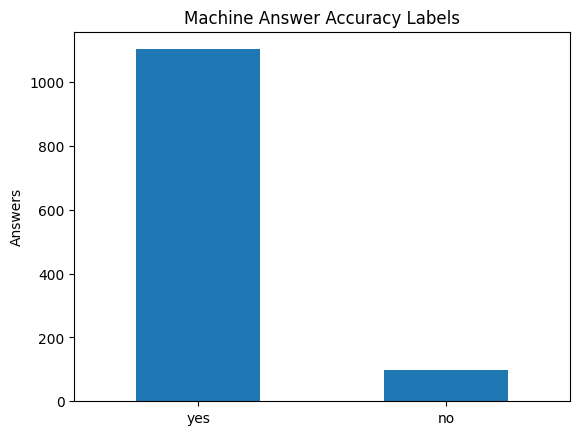

In [12]:
accuracy_counts.plot(kind="bar")
plt.title("Machine Answer Accuracy Labels")
plt.xlabel("")
plt.ylabel("Answers")
plt.xticks(rotation=0)
plt.show()

## Example

In [13]:
example = data[0]

print("question:")
print(example["question"])

print("\nexpert answer:")
print(example["expert_curated_answer"])

print("\nmachine answer (M1):")
print(example["machine_generated_answers"]["M1"]["answer"])

print("\naccurate:")
print(example["machine_generated_answers"]["M1"]["is_answer_accurate"])

question:
Are there ways to prevent sleep apnea or treat it naturally?

expert answer:
 There are ways to prevent and treat sleep apnea naturally. Lifestyle changes may prevent and treat sleep apnea [28646811, 33659106, 28659501, 12693795, 36617387]. Sleep apnea can be prevented by losing weight and keeping it down with diet and exercise [33659106, 12693795, 30204000, 36617387, 28659501]; quitting alcohol and smoking [33659106, 12693795, 36617387]; and changing sleep position [12693795, 22987061, 30204000, 36617387]. While Continuous Positive Airway Pressure (CPAP, a machine that uses mild air pressure to keep breathing airways open while you sleep) is the standard treatment for obstructive sleep apnea (OSA) [28901030, 35909585], Chinese massage Tui Na [28646811], dental treatments to change teeth and jaw position [12693795, 36617387, 28901030]; and exercises for tongue and throat [28901030] reduce snoring and apnea. Treatments with drugs [30204000, 22987061], nerve stimulation [229870

## Findings

- MedAESQA has 40 questions and 30 machine-generated answers for each question.
- The main fields are complete.
- The questions cover factoid, effect, and decision support tasks. `Decision Support` shows up with two capitalization styles, so I combined them for the plot.
- Expert and machine answers are pretty similar in average length.
- Most machine answers are labeled accurate, so the accuracy labels are not balanced.
- The expert nuggets and human labels can help us check whether FaithfulMed keeps the important medical information and stays faithful to the source.
- With only 40 questions, this dataset makes more sense for evaluation than training.